After I realized the issues that I had with the data I took, I decided to break things up a bit, so that I could more easily manage the analysis.\
\
Tests 0-2, 7, and 11-18 are all 13/05/26\
Tests 3-6 and 8-10 are all 14/05/26 \
Tests 19-22 are all 22/05/26\
Tests 23-26 are all 25/05/26\
Tests 27-30 are all 26/05/27

In [112]:
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.concat([pd.read_excel(f"timing_results/May13_{i}.xlsx",sheet_name="General") for i in range(1,4)])
ch0_13,ch1_13,ch2_13,aggreg_13 = df['Channel 0'],df['Channel 1'],df['Channel 2'],df['All Channels']
df = pd.concat([pd.read_excel(f"timing_results/May14_{i}.xlsx",sheet_name="General") for i in range(1,3)])
ch0_14,ch1_14,ch2_14,aggreg_14 = df['Channel 0'],df['Channel 1'],df['Channel 2'],df['All Channels']
df = pd.read_excel(f"timing_results/May22_1.xlsx",sheet_name="General")
ch0_22,ch1_22,ch2_22,aggreg_22 = df['Channel 0'],df['Channel 1'],df['Channel 2'],df['All Channels']
df = pd.read_excel(f"timing_results/May25_1.xlsx",sheet_name="General")
ch0_25,ch1_25,ch2_25,aggreg_25 = df['Channel 0'],df['Channel 1'],df['Channel 2'],df['All Channels']
df = pd.read_excel(f"timing_results/May26_1.xlsx",sheet_name="General")
ch0_26,ch1_26,ch2_26,aggreg_26 = df['Channel 0'],df['Channel 1'],df['Channel 2'],df['All Channels']

event_rate,n_events = [],[]
for day in [[ch0_13,ch1_13,ch2_13],[ch0_14,ch1_14,ch2_14],[ch0_22,ch1_22,ch2_22],[ch0_25,ch1_25,ch2_25],[ch0_26,ch1_26,ch2_26]]:
   event_rate_day ,n_events_day = [],[]
   for ch in day:
      ch_event_rate = np.array(ch)[3::5]
      ch_event_rate = np.array([np.array(er.split(" ± "),dtype=np.float64) for er in ch_event_rate])
      event_rate_day.append(ch_event_rate)
      ch_n_events = np.array(ch)[1::5]
      n_events_day.append(ch_n_events)
   event_rate.append(event_rate_day)
   n_events.append(n_events_day)

print(n_events[2])

[array([1205, 2730, 2505, 7205], dtype=object), array([1205, 2730, 2505, 7205], dtype=object), array([1205, 2730, 2505, 7205], dtype=object)]


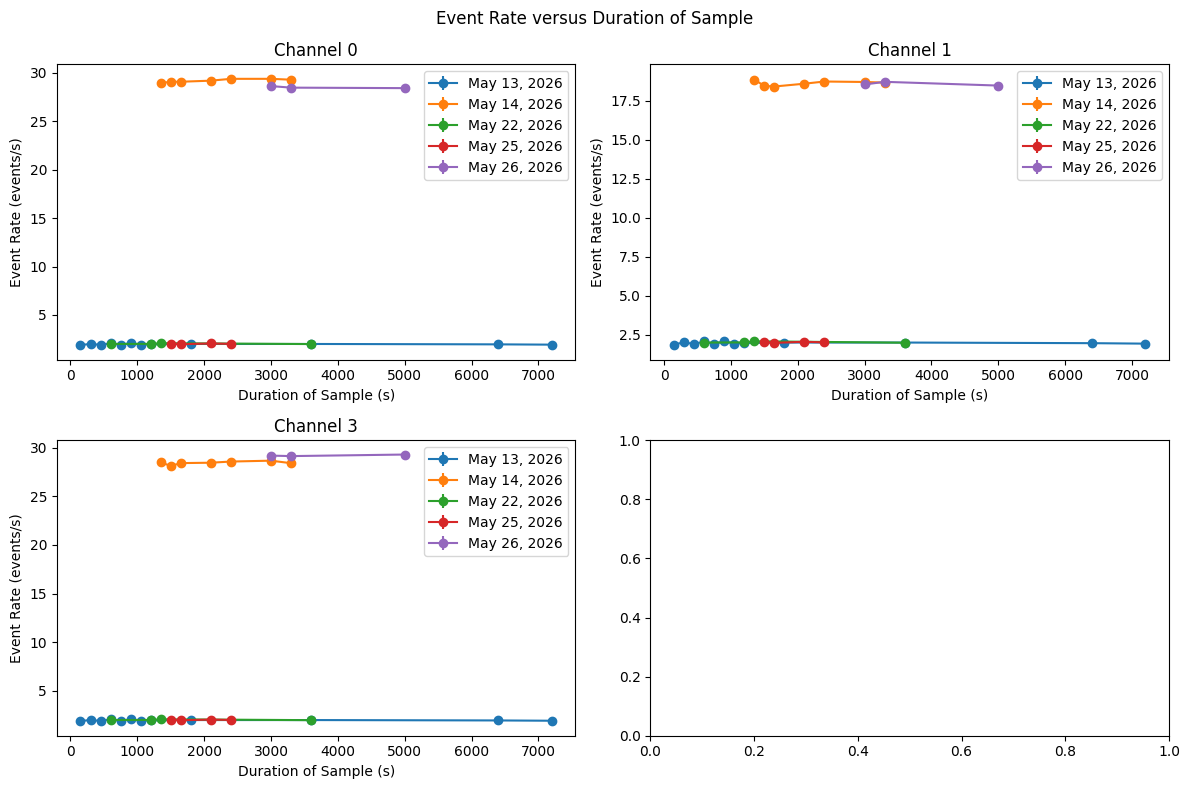

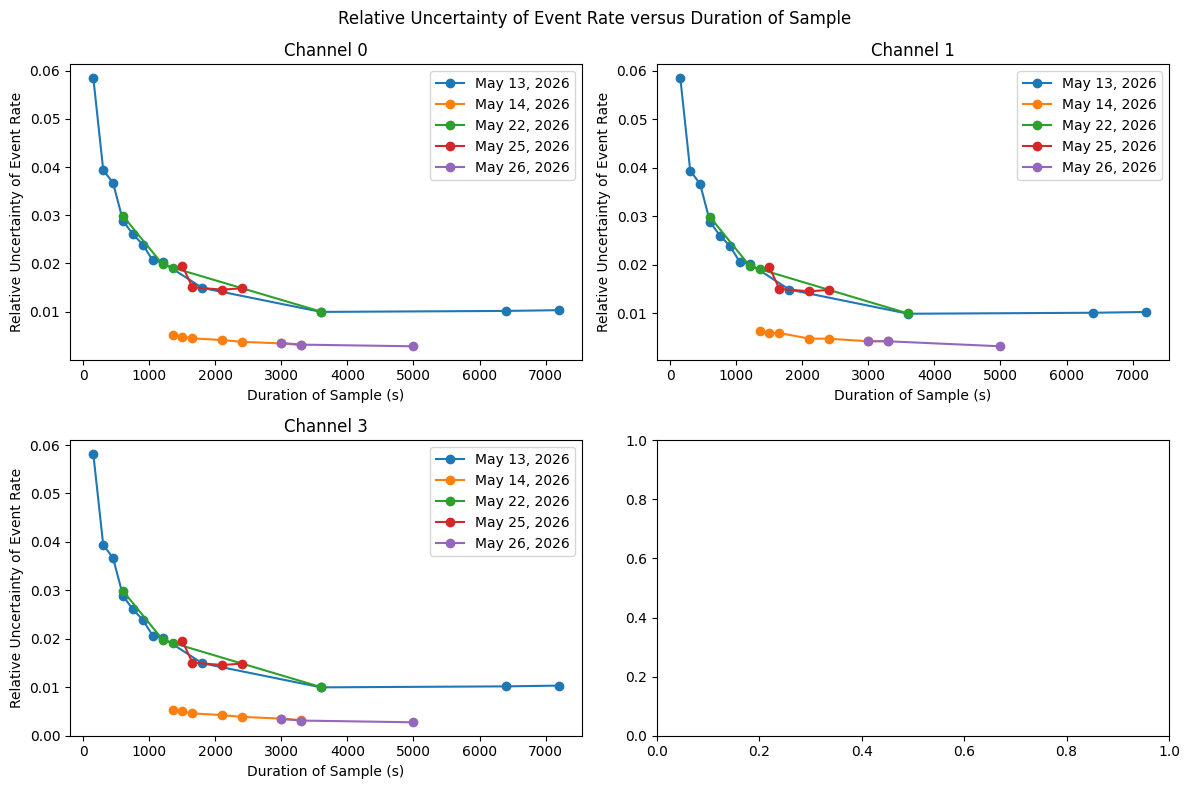

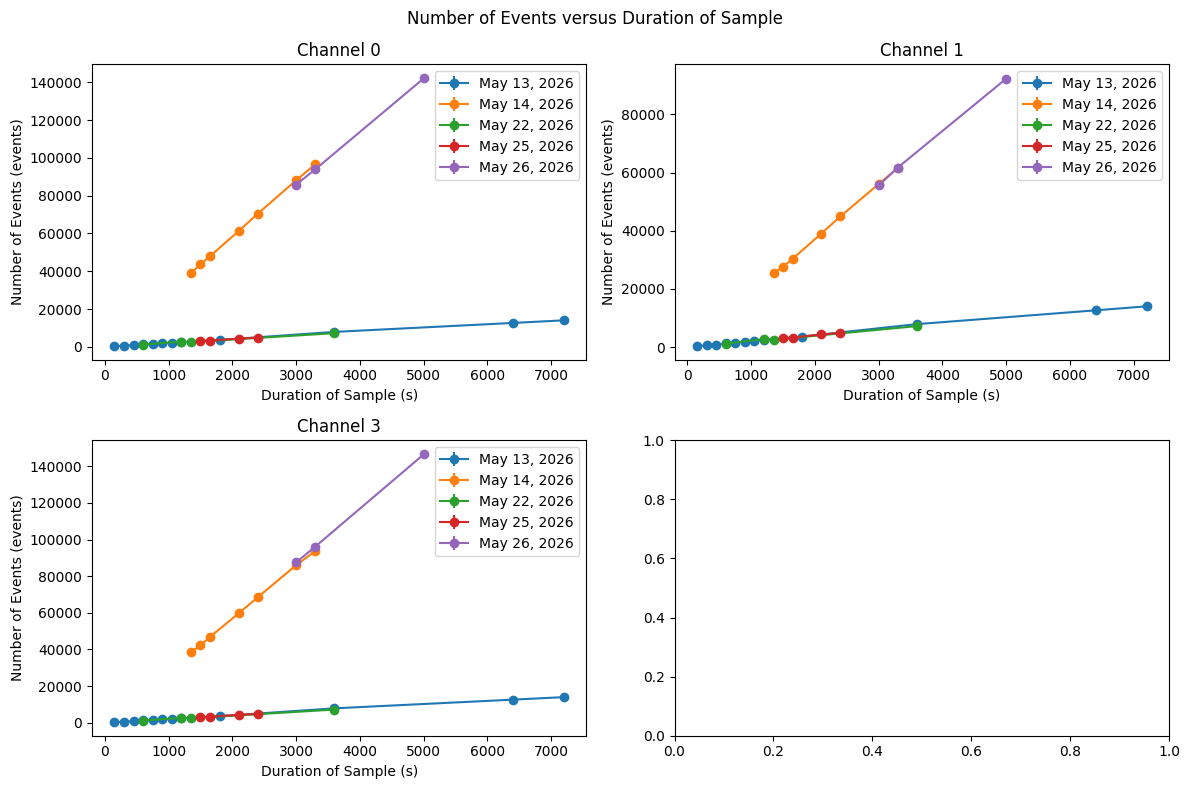

In [114]:
durations = [[7200,6400,3600,1800,1200,1050,900,750,600,450,300,150],[3300,3000,2400,2100,1650,1500,1350],[600,1200,1350,3600],[1500,1650,2100,2400],[3000,3300,5000]]
days = ["May 13, 2026","May 14, 2026","May 22, 2026","May 25, 2026","May 26, 2026"]
sizes = [3,2,1,1,1]

fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle(f"Event Rate versus Duration of Sample")
for i in range(2):
   axs[0,i].set_title(f"Channel {i}")
   axs[0,i].set_xlabel("Duration of Sample (s)")
   axs[0,i].set_ylabel("Event Rate (events/s)")
   for j in range(len(event_rate)):
      axs[0,i].errorbar(durations[j],np.array(event_rate[j][i])[:,0],label=days[j],marker='o',yerr=np.array(event_rate[j][i])[:,1])
   axs[0,i].legend()
axs[1,0].set_title(f"Channel 3")
axs[1,0].set_xlabel("Duration of Sample (s)")
axs[1,0].set_ylabel("Event Rate (events/s)")
for j in range(len(event_rate)):
   axs[1,0].errorbar(durations[j],np.array(event_rate[j][2])[:,0],label=days[j],marker='o',yerr=np.array(event_rate[j][2])[:,1])
axs[1,0].legend()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle(f"Relative Uncertainty of Event Rate versus Duration of Sample")
for i in range(2):
   axs[0,i].set_title(f"Channel {i}")
   axs[0,i].set_xlabel("Duration of Sample (s)")
   axs[0,i].set_ylabel("Relative Uncertainty of Event Rate")
   for j in range(len(event_rate)):
      axs[0,i].plot(durations[j],np.array(event_rate[j][i])[:,1]/np.array(event_rate[j][i])[:,0],label=days[j],marker='o')
   axs[0,i].legend()
axs[1,0].set_title(f"Channel 3")
axs[1,0].set_xlabel("Duration of Sample (s)")
axs[1,0].set_ylabel("Relative Uncertainty of Event Rate")
for j in range(len(event_rate)):
   axs[1,0].plot(durations[j],np.array(event_rate[j][2])[:,1]/np.array(event_rate[j][2])[:,0],label=days[j],marker='o')
axs[1,0].legend()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle(f"Number of Events versus Duration of Sample")
for i in range(2):
   axs[0,i].set_title(f"Channel {i}")
   axs[0,i].set_xlabel("Duration of Sample (s)")
   axs[0,i].set_ylabel("Number of Events (events)")
   for j in range(len(event_rate)):
      axs[0,i].errorbar(durations[j],np.array(n_events[j][i]),label=days[j],marker='o',yerr=[np.sqrt(n_ji) for n_ji in np.array(n_events[j][i])])
   axs[0,i].legend()
axs[1,0].set_title(f"Channel 3")
axs[1,0].set_xlabel("Duration of Sample (s)")
axs[1,0].set_ylabel("Number of Events (events)")
for j in range(len(event_rate)):
   axs[1,0].errorbar(durations[j],np.array(n_events[j][2]),label=days[j],marker='o',yerr=[np.sqrt(n_j2) for n_j2 in np.array(n_events[j][2])])
axs[1,0].legend()

plt.tight_layout()
plt.show()

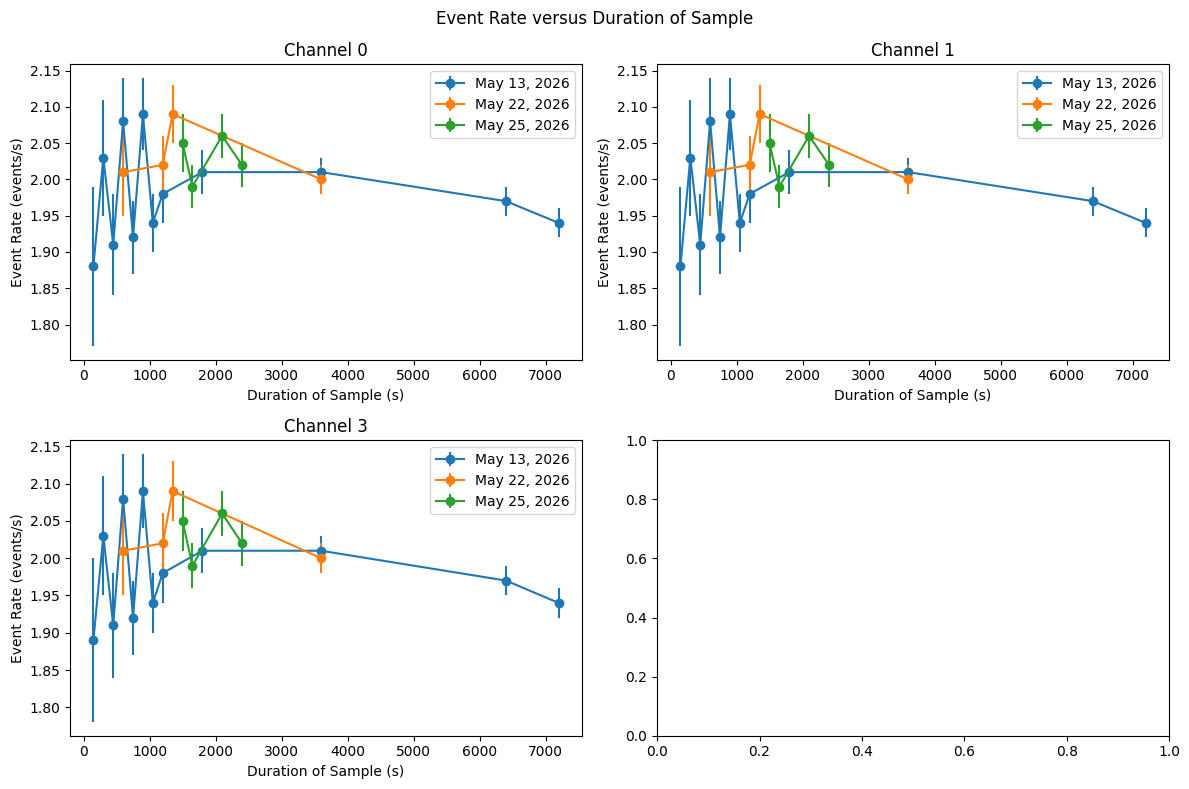

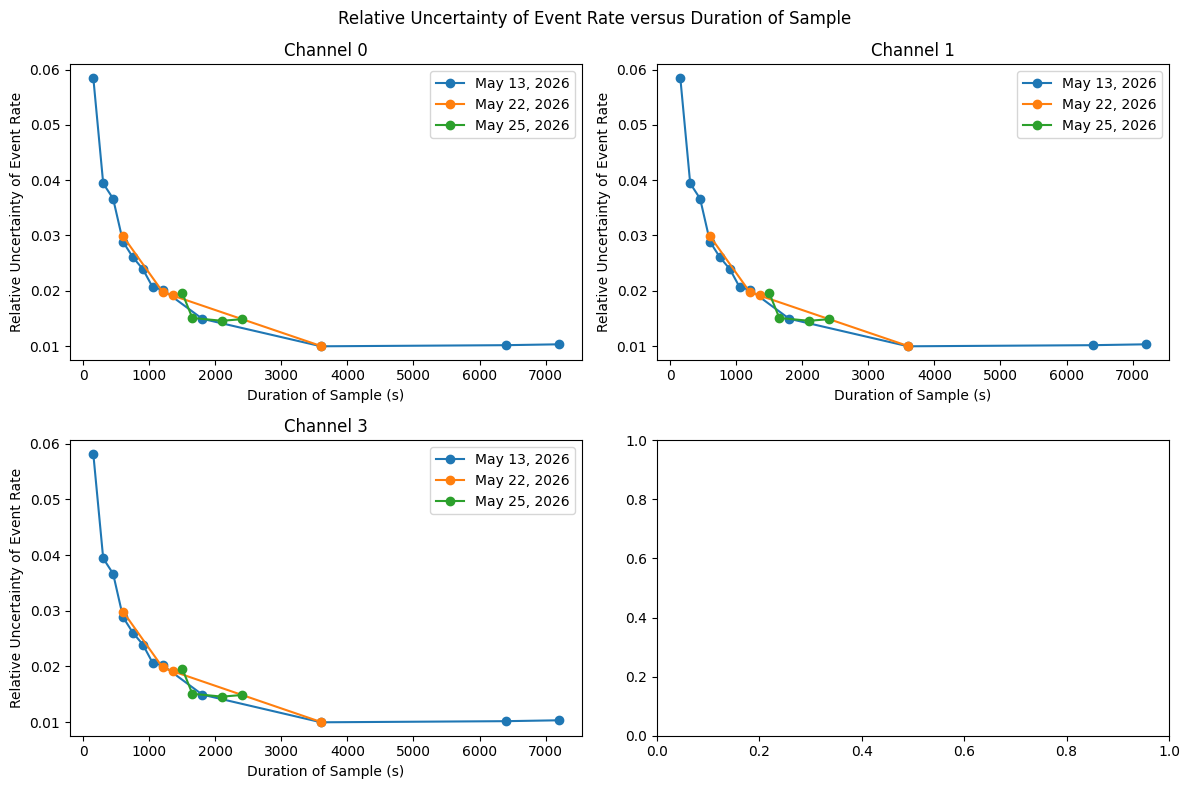

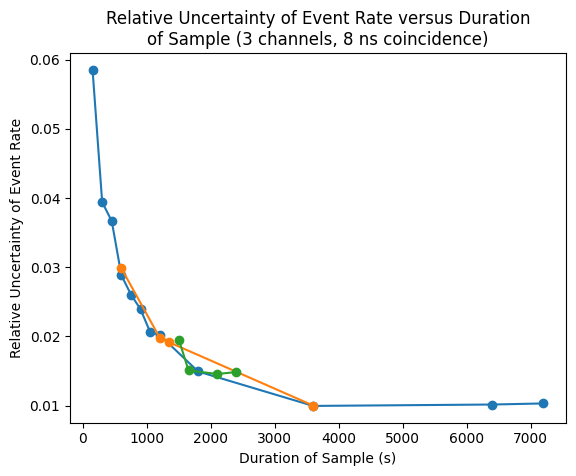

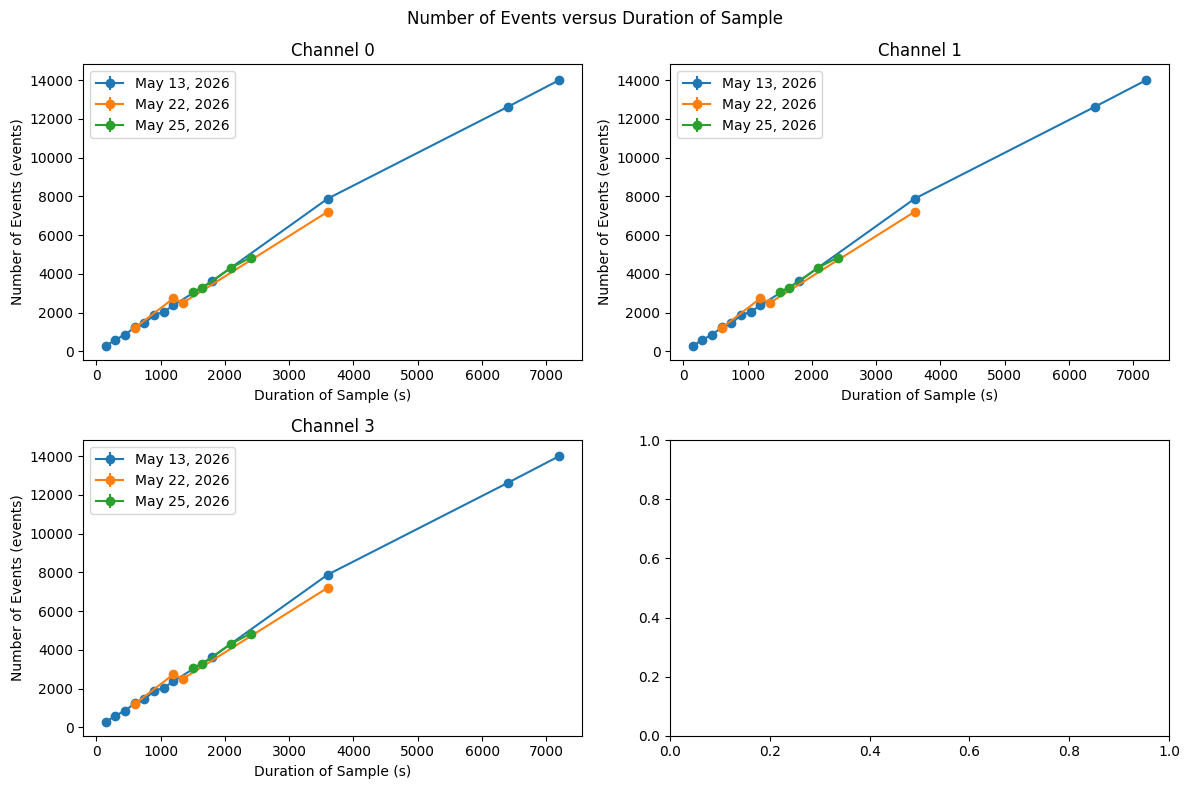

In [115]:
from copy import deepcopy

new_durations = deepcopy(durations)
new_days = deepcopy(days)
new_event_rate = deepcopy(event_rate)
new_n_events = deepcopy(n_events)
new_sizes = deepcopy(sizes)
[new_durations.pop(i) for i in [1,-1]]
[new_days.pop(i) for i in [1,-1]]
[new_event_rate.pop(i) for i in [1,-1]]
[new_n_events.pop(i) for i in [1,-1]]
[new_sizes.pop(i) for i in [1,-1]]

fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle(f"Event Rate versus Duration of Sample")
for i in range(2):
   axs[0,i].set_title(f"Channel {i}")
   axs[0,i].set_xlabel("Duration of Sample (s)")
   axs[0,i].set_ylabel("Event Rate (events/s)")
   for j in range(len(new_event_rate)):
      axs[0,i].errorbar(new_durations[j],np.array(new_event_rate[j][i])[:,0],label=new_days[j],marker='o',yerr=np.array(new_event_rate[j][i])[:,1])
   axs[0,i].legend()
axs[1,0].set_title(f"Channel 3")
axs[1,0].set_xlabel("Duration of Sample (s)")
axs[1,0].set_ylabel("Event Rate (events/s)")
for j in range(len(new_event_rate)):
   axs[1,0].errorbar(new_durations[j],np.array(new_event_rate[j][2])[:,0],label=new_days[j],marker='o',yerr=np.array(new_event_rate[j][2])[:,1])
axs[1,0].legend()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle(f"Relative Uncertainty of Event Rate versus Duration of Sample")
for i in range(2):
   axs[0,i].set_title(f"Channel {i}")
   axs[0,i].set_xlabel("Duration of Sample (s)")
   axs[0,i].set_ylabel("Relative Uncertainty of Event Rate")
   for j in range(len(new_event_rate)):
      axs[0,i].plot(new_durations[j],np.array(new_event_rate[j][i])[:,1]/np.array(new_event_rate[j][i])[:,0],label=new_days[j],marker='o')
   axs[0,i].legend()
axs[1,0].set_title(f"Channel 3")
axs[1,0].set_xlabel("Duration of Sample (s)")
axs[1,0].set_ylabel("Relative Uncertainty of Event Rate")
for j in range(len(new_event_rate)):
   axs[1,0].plot(new_durations[j],np.array(new_event_rate[j][2])[:,1]/np.array(new_event_rate[j][2])[:,0],label=new_days[j],marker='o')
axs[1,0].legend()

plt.tight_layout()
plt.show()

plt.figure()
plt.title(f"Relative Uncertainty of Event Rate versus Duration\nof Sample (3 channels, 8 ns coincidence)")
plt.xlabel("Duration of Sample (s)")
plt.ylabel("Relative Uncertainty of Event Rate")
for j in range(len(new_event_rate)):
   plt.plot(new_durations[j],np.array(new_event_rate[j][0])[:,1]/np.array(new_event_rate[j][0])[:,0],label=new_days[j],marker='o')
plt.show()

fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle(f"Number of Events versus Duration of Sample")
for i in range(2):
   axs[0,i].set_title(f"Channel {i}")
   axs[0,i].set_xlabel("Duration of Sample (s)")
   axs[0,i].set_ylabel("Number of Events (events)")
   for j in range(len(new_event_rate)):
      axs[0,i].errorbar(new_durations[j],np.array(new_n_events[j][i]),label=new_days[j],marker='o',yerr=[np.sqrt(n_ji) for n_ji in np.array(new_n_events[j][i])])
   axs[0,i].legend()
axs[1,0].set_title(f"Channel 3")
axs[1,0].set_xlabel("Duration of Sample (s)")
axs[1,0].set_ylabel("Number of Events (events)")
for j in range(len(new_event_rate)):
   axs[1,0].errorbar(new_durations[j],np.array(new_n_events[j][2]),label=new_days[j],marker='o',yerr=[np.sqrt(n_j2) for n_j2 in np.array(new_n_events[j][2])])
axs[1,0].legend()

plt.tight_layout()
plt.show()

We see no difference in the event rates because the number of events and the duration of samples is actually so close between channels, so from now on I will only do one channel plot for event rate and number of events

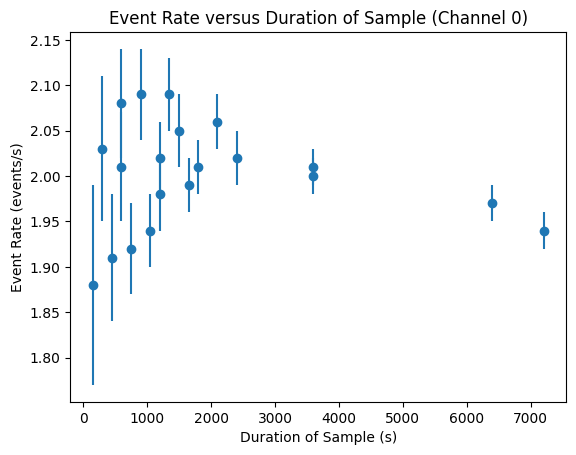

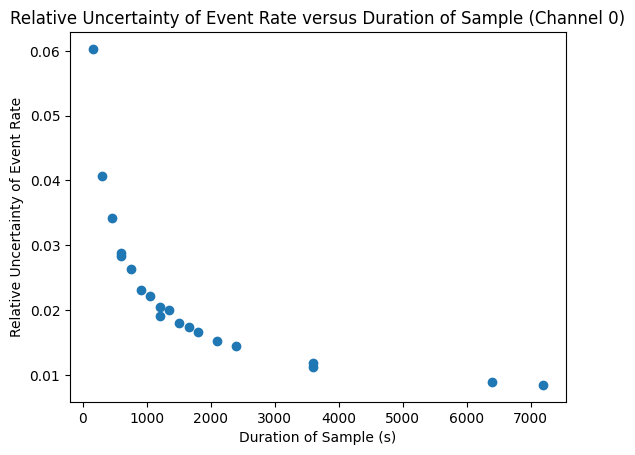

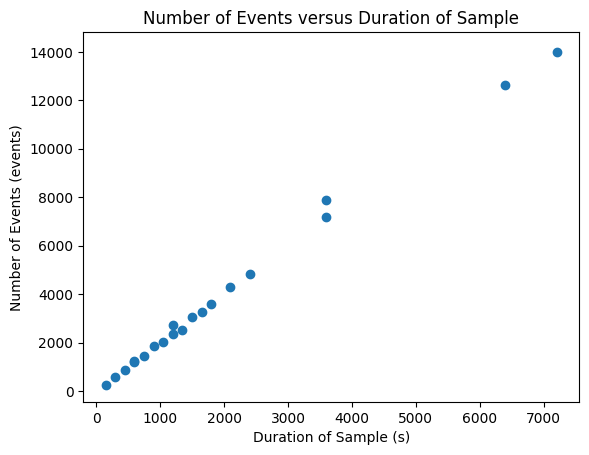

In [116]:
joined_durations = np.array([item for sublist in new_durations for item in sublist])
joined_days = np.array(deepcopy(new_days))
joined_event_rate = np.array([item for sublist in [day[0] for day in new_event_rate] for item in sublist])
joined_n_events = np.array([item for sublist in [day[0] for day in new_n_events] for item in sublist])

event_rate_err = joined_event_rate[:,1]
joined_event_rate = joined_event_rate[:,0]
n_events_err = np.sqrt(joined_n_events)
event_rate_rel_err = 1/n_events_err


plt.title(f"Event Rate versus Duration of Sample (Channel 0)")
plt.xlabel("Duration of Sample (s)")
plt.ylabel("Event Rate (events/s)")
plt.errorbar(joined_durations,joined_event_rate,marker='o',linestyle='',yerr=event_rate_err)
plt.show()

plt.title(f"Relative Uncertainty of Event Rate versus Duration of Sample (Channel 0)")
plt.xlabel("Duration of Sample (s)")
plt.ylabel("Relative Uncertainty of Event Rate")
plt.plot(joined_durations,event_rate_rel_err,marker='o',linestyle='')
plt.show()

plt.title(f"Number of Events versus Duration of Sample")
plt.xlabel("Duration of Sample (s)")
plt.ylabel("Number of Events (events)")
plt.errorbar(joined_durations,joined_n_events,marker='o',linestyle='',yerr=n_events_err)
plt.show()

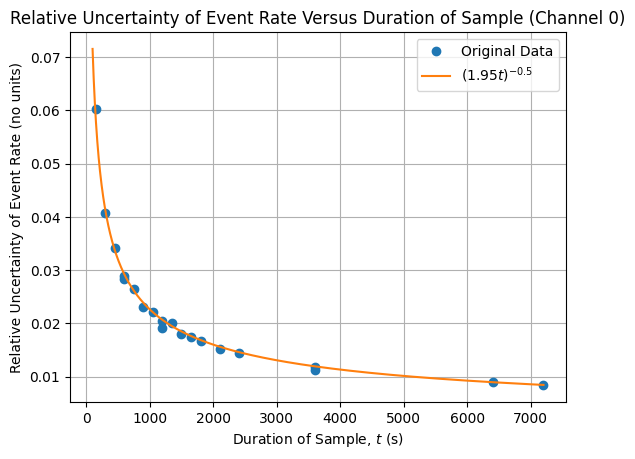

In [117]:
from scipy.optimize import curve_fit

def g(x,b):
   return 1 / np.sqrt(x * b)

popt_g,pcov_g = curve_fit(g,joined_durations,event_rate_rel_err,p0=[1.99], ftol=1e-12, xtol=1e-12, gtol=1e-12)

x = np.linspace(100,7200,2000)
plt.title("Relative Uncertainty of Event Rate Versus Duration of Sample (Channel 0)")
plt.ylabel("Relative Uncertainty of Event Rate (no units)")
plt.xlabel("Duration of Sample, $t$ (s)")
plt.plot(joined_durations,event_rate_rel_err,label="Original Data",marker="o",linestyle="")
plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$")
plt.grid()
plt.legend()
plt.show()

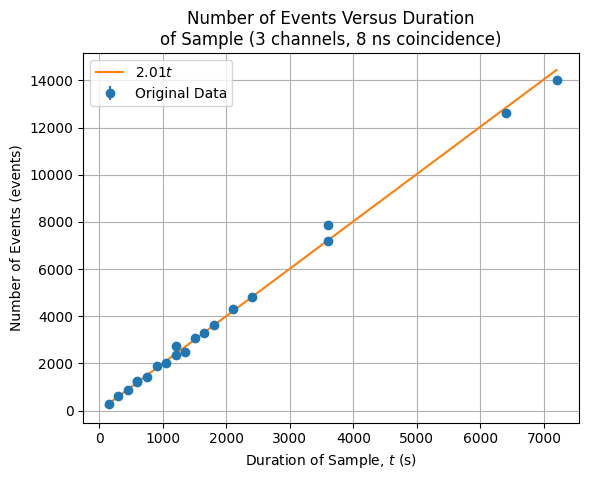

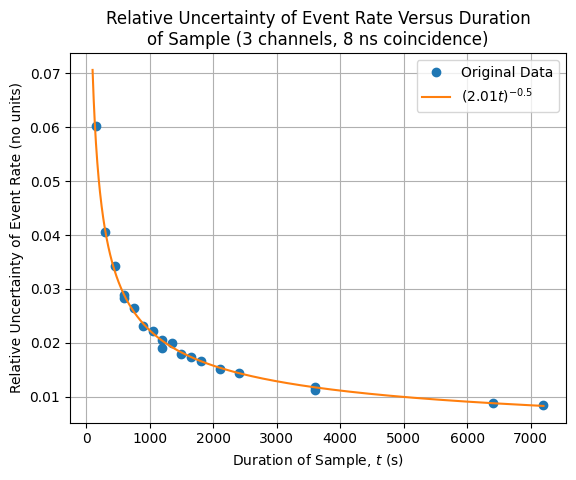

Without accounting for errors in $N$, $b=1.99$
$\chi^2$for $b=1.99$ is 3.09e-04
$\chi^2$for $b=2.01$ is 3.22e-04
$\chi^2$for $b=1.95$ is 3.26e-04


In [118]:
from scipy.optimize import curve_fit

def chi2(exp,obs):
   return np.sum((exp-obs)**2/exp)

def f(x,b):
   return x * b

popt,pcov = curve_fit(f,joined_durations,joined_n_events,p0=[1.95],sigma=n_events_err, ftol=1e-12, xtol=1e-12, gtol=1e-12)

x = np.linspace(100,7200,2000)
plt.title("Number of Events Versus Duration\nof Sample (3 channels, 8 ns coincidence)")
plt.ylabel("Number of Events (events)")
plt.xlabel("Duration of Sample, $t$ (s)")
plt.errorbar(joined_durations,joined_n_events,label="Original Data",marker="o",linestyle="",yerr=n_events_err)
plt.plot(x,f(x, *popt),label=f"{popt[0]:.2f}$t$")
plt.grid()
plt.legend()
plt.show()

plt.title("Relative Uncertainty of Event Rate Versus Duration\nof Sample (3 channels, 8 ns coincidence)")
plt.ylabel("Relative Uncertainty of Event Rate (no units)")
plt.xlabel("Duration of Sample, $t$ (s)")
plt.plot(joined_durations,event_rate_rel_err,label="Original Data",marker="o",linestyle="")
plt.plot(x,g(x, *popt),label=f"({popt[0]:.2f}"+r"$t)^{-0.5}$")
plt.grid()
plt.legend()
plt.show()

print(f"Without accounting for errors in $N$, $b={curve_fit(f,joined_durations,joined_n_events,p0=[1.95,])[0][0]:.2f}$")
print(r"$\chi^2$" + f"for $b={curve_fit(f,joined_durations,joined_n_events,p0=[1.95,])[0][0]:.2f}$ is {chi2(g(joined_durations, curve_fit(f,joined_durations,joined_n_events,p0=[1.95,])[0][0]),event_rate_rel_err):.2e}")
print(r"$\chi^2$" + f"for $b={popt[0]:.2f}$ is {chi2(g(joined_durations, *popt),event_rate_rel_err):.2e}")
print(r"$\chi^2$" + f"for $b={popt_g[0]:.2f}$ is {chi2(g(joined_durations, *popt_g),event_rate_rel_err):.2e}")

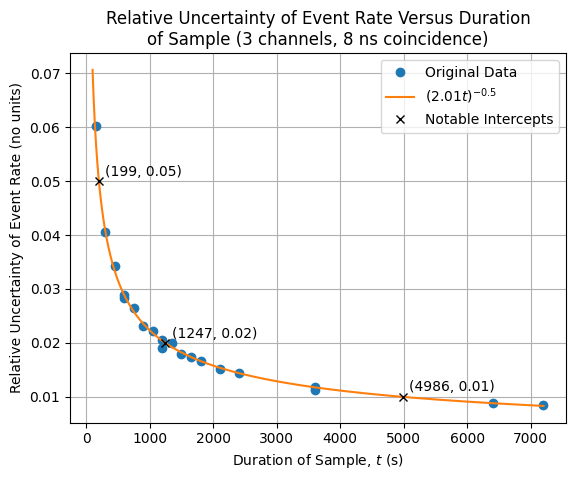

For less than 5% error, a sample duration greater than 199.44 s is needed
For less than 2.5% error, a sample duration greater than 797.77 s is needed
For less than 2% error, a sample duration greater than 1246.51 s is needed
For less than 1% error, a sample duration greater than 4986.04 s is needed


In [119]:
# Find intercepts for 5%, 2.5%, and 1% error
from scipy.optimize import root_scalar

perc5 = root_scalar(lambda t : g(t, *popt)-0.05, bracket=[100,500]).root
perc25 = root_scalar(lambda t : g(t, *popt)-0.025, bracket=[500,1000]).root
perc2 = root_scalar(lambda t : g(t, *popt)-0.02, bracket=[1000,1500]).root
perc1 = root_scalar(lambda t : g(t, *popt)-0.01, bracket=[4700,5300]).root

plt.title("Relative Uncertainty of Event Rate Versus Duration\nof Sample (3 channels, 8 ns coincidence)")
plt.ylabel("Relative Uncertainty of Event Rate (no units)")
plt.xlabel("Duration of Sample, $t$ (s)")
plt.plot(joined_durations,event_rate_rel_err,label="Original Data",marker="o",linestyle="")
plt.plot(x,g(x, *popt),label=f"({popt[0]:.2f}"+r"$t)^{-0.5}$")
plt.plot([perc5,perc2,perc1],[0.05,0.02,0.01],marker='x',linestyle='',label='Notable Intercepts',color='black')
plt.annotate(f"({perc5:.0f}, 0.05)", (perc5+100,0.05+0.001), xytext=None, arrowprops=None)
plt.annotate(f"({perc2:.0f}, 0.02)", (perc2+100,0.02+0.001), xytext=None, arrowprops=None)
plt.annotate(f"({perc1:.0f}, 0.01)", (perc1+100,0.01+0.001), xytext=None, arrowprops=None)
plt.grid()
plt.legend()
plt.show()

print(f"For less than 5% error, a sample duration greater than {perc5:.2f} s is needed")
print(f"For less than 2.5% error, a sample duration greater than {perc25:.2f} s is needed")
print(f"For less than 2% error, a sample duration greater than {perc2:.2f} s is needed")
print(f"For less than 1% error, a sample duration greater than {perc1:.2f} s is needed")

In [ ]:
langaus_data = []
for i in range(len(new_days)):
   day = new_days[i][4:6]
   df = pd.concat([pd.read_excel(f"timing_results/May{day}_{j}.xlsx",sheet_name="Landau-Gaussian Height") for j in range(1,new_sizes[i]+1)])
   df = df.sort_values(by='Channel',kind='mergesort')
   grouped = [group for _, group in df.groupby('Channel')]
   day_stats = []
   for ch in grouped:
      ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['c'], ch['mu'], ch['mean'], ch['std'], ch['sigma_c'], ch['sigma_mu'], ch['sigma_mean'], ch['sigma_std'], ch['0.10% Threshold']])
      day_stats.append(ch_stats)
   langaus_data.append(np.array(day_stats))

print(len(langaus_data))
print([langaus_data[i].shape for i in range(len(langaus_data))])

print("Days, Channel, Stat, Sample")

3
[(4, 10, 12), (4, 10, 4), (4, 10, 4)]
Days, Channel, Stat, Sample


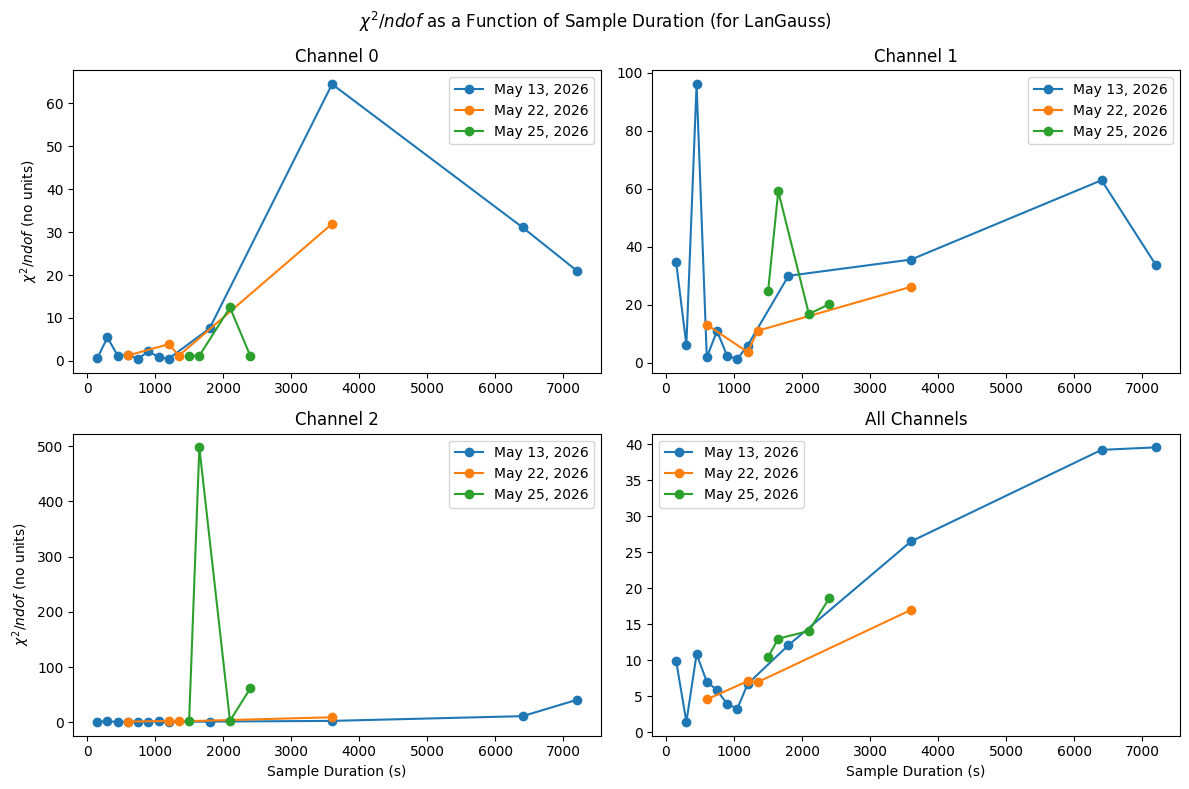

In [121]:
fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle(r"$\chi^2/ndof$ as a Function of Sample Duration (for LanGauss)")
axs[0,0].set_ylabel(r"$\chi^2/ndof$ (no units)")
axs[1,0].set_ylabel(r"$\chi^2/ndof$ (no units)")
axs[1,0].set_xlabel("Sample Duration (s)")
axs[1,1].set_xlabel("Sample Duration (s)")
for i in range(2):
   for j in range(2):
      ch = i*2+j
      axs[i,j].set_title(f"Channel {ch}")
      for k in range(len(new_days)):
         axs[i,j].plot(new_durations[k],langaus_data[k][ch][0],label=f"{new_days[k]}",marker='o',linestyle='-')
      axs[i,j].legend()
axs[1,1].set_title(f"All Channels")

plt.tight_layout()
plt.show()

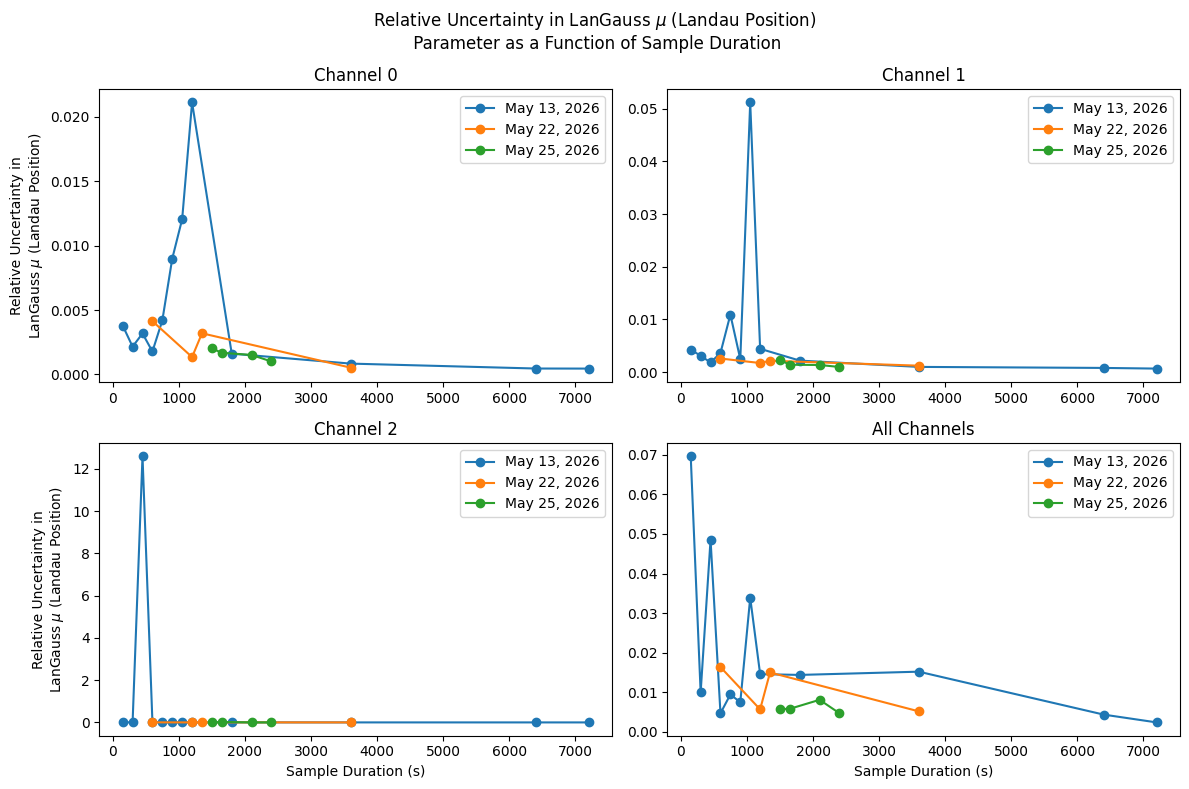

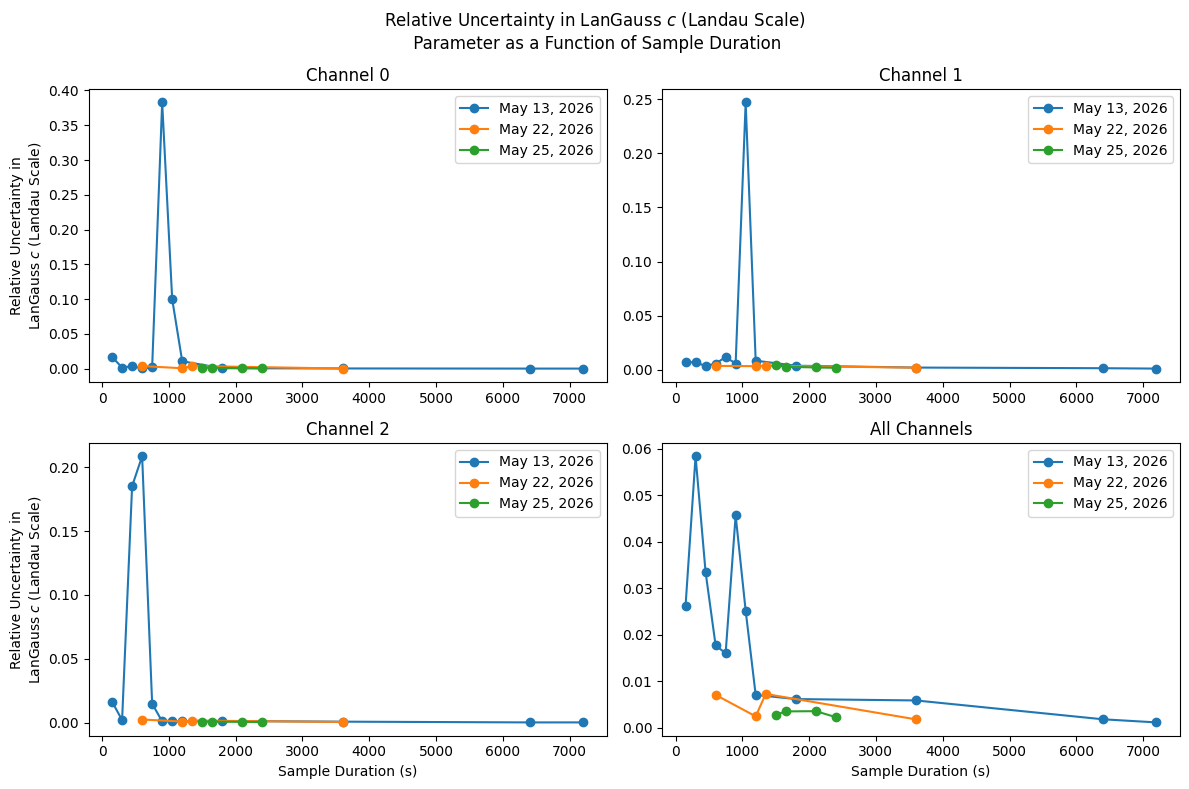

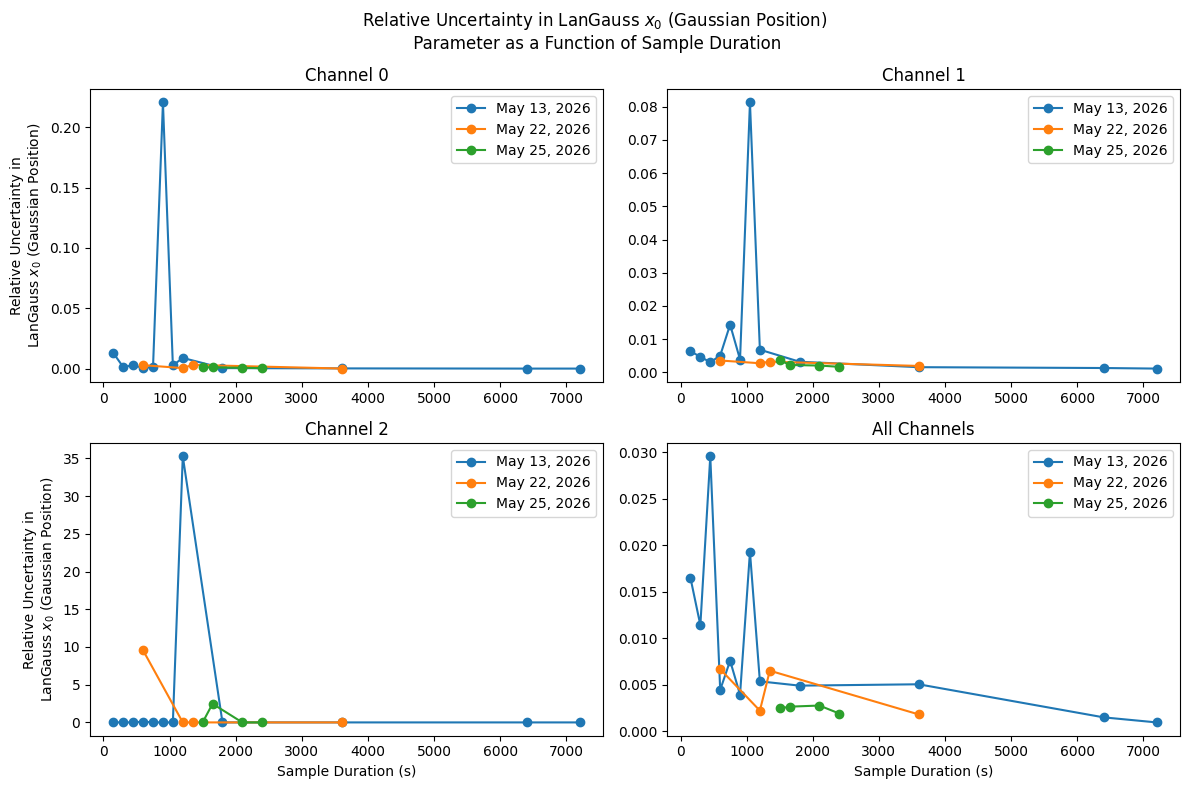

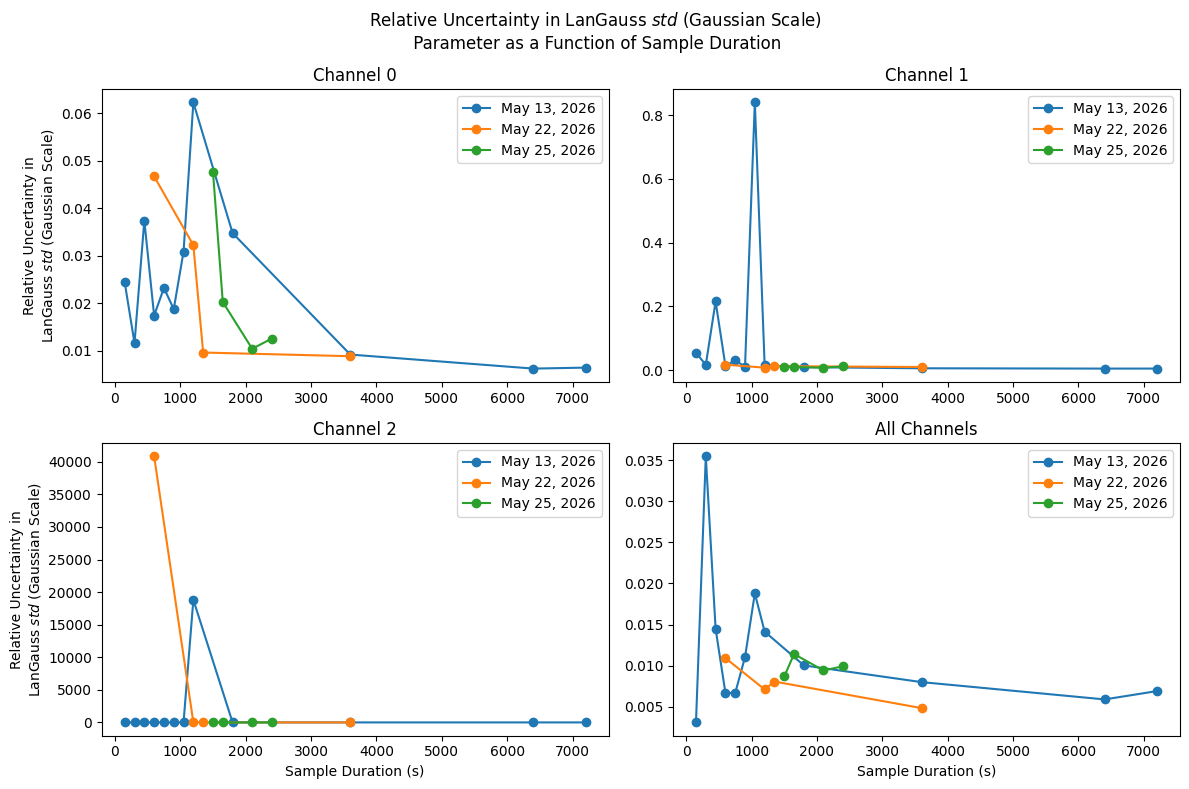

In [122]:
parameter_labels = [
   r'LanGauss $\mu$ (Landau Position)',
   'LanGauss $c$ (Landau Scale)',
   'LanGauss $x_0$ (Gaussian Position)',
   'LanGauss $std$ (Gaussian Scale)',
]
for l in range(len(parameter_labels)):
   title = "Relative Uncertainty in " + parameter_labels[l] + "\n Parameter as a Function of Sample Duration"
   ylabel = "Relative Uncertainty in\n" + parameter_labels[l]
   fig, axs = plt.subplots(2,2,figsize=(12,8))
   plt.suptitle(title)
   axs[0,0].set_ylabel(ylabel)
   axs[1,0].set_ylabel(ylabel)
   axs[1,0].set_xlabel("Sample Duration (s)")
   axs[1,1].set_xlabel("Sample Duration (s)")
   for i in range(2):
      for j in range(2):
         ch = i*2+j
         axs[i,j].set_title(f"Channel {ch}")
         for k in range(len(new_days)):
            axs[i,j].plot(new_durations[k],langaus_data[k][ch][5+l]/langaus_data[k][ch][1+l],label=f"{new_days[k]}",marker='o',linestyle='-')
            # for p in range(len(durations[k])):
            #    if durations[k][p]==1050 and ch==2:
            #       print(f"{langaus_data[k][ch][1+l][p]} pm {langaus_data[k][ch][5+l][p]}")
                  
         axs[i,j].legend()
   axs[1,1].set_title(f"All Channels")

   plt.tight_layout()
   plt.show()

It looks like the fit really went wrong a couple of times, especially for May 14/16th data. I am going to remove those points

In [123]:
bad_indices = []

for l in range(len(parameter_labels)):
   for ch in range(4):
      for day in range(len(new_days)):
         for point in range(len(new_durations[day])):
            if langaus_data[day][ch][5+l][point]/langaus_data[day][ch][1+l][point]>1:
               bad_indices.append((day,ch,l,point))
                  
sorted_bad = sorted(bad_indices, key=lambda x: x[0])
print("Day | Channel | Stat | Duration")
print("-------------------------------")
for bad in sorted_bad:
   print(f"{bad[0]:3} | {bad[1]:7} | {bad[2]:4} | {new_durations[bad[0]][bad[3]]:6} s")

Day | Channel | Stat | Duration
-------------------------------
  0 |       2 |    0 |    450 s
  0 |       2 |    2 |   1200 s
  0 |       2 |    3 |   1200 s
  1 |       2 |    2 |    600 s
  1 |       2 |    3 |    600 s
  2 |       2 |    2 |   1650 s


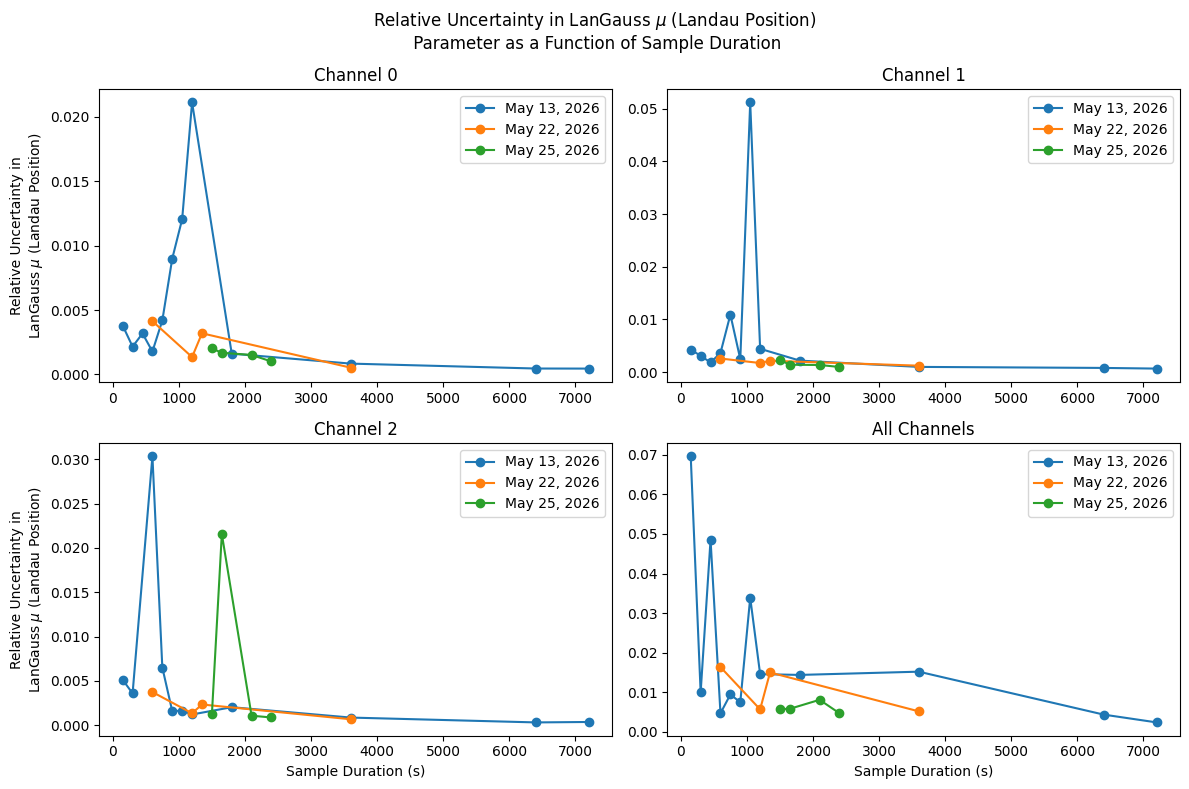

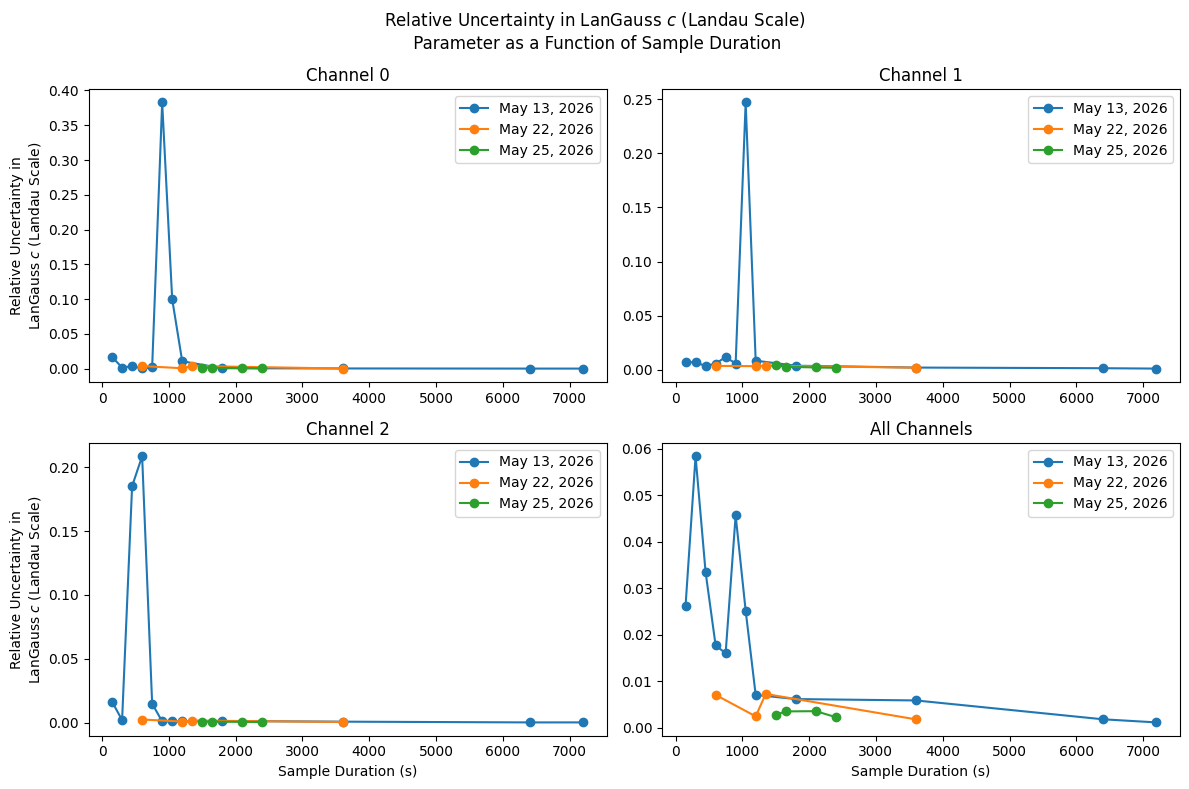

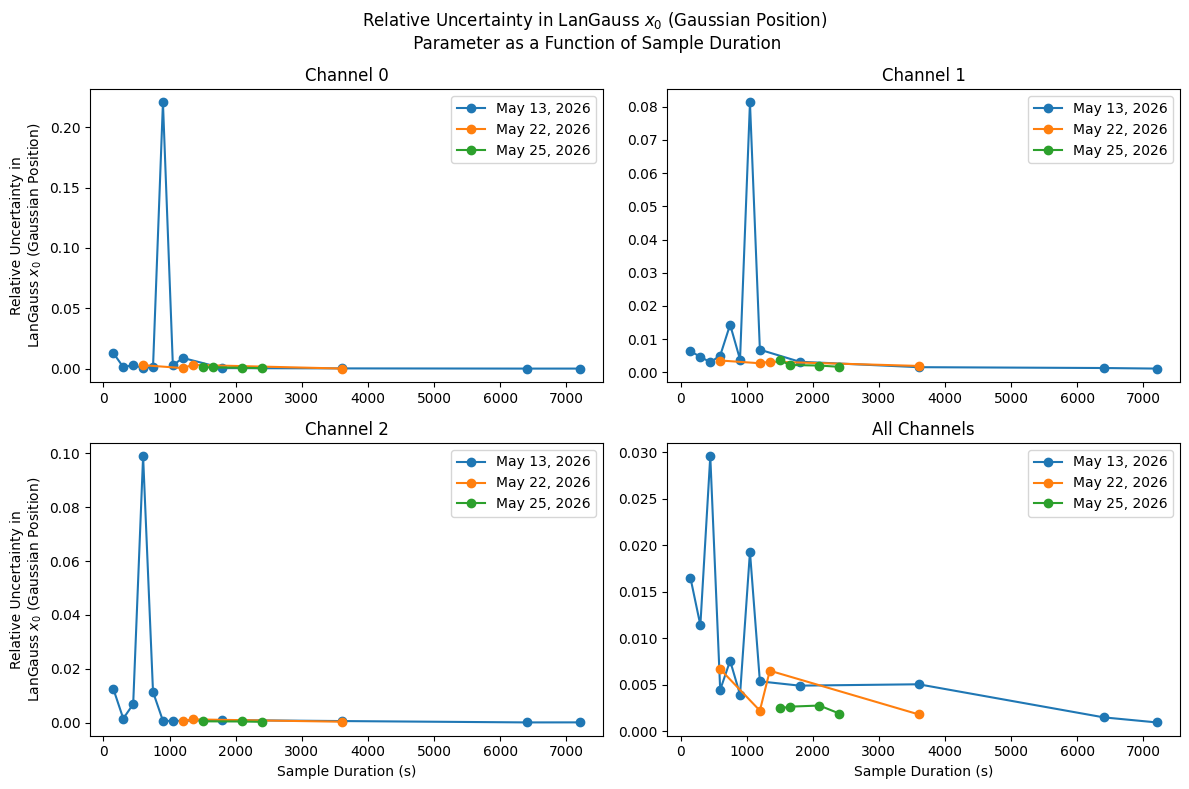

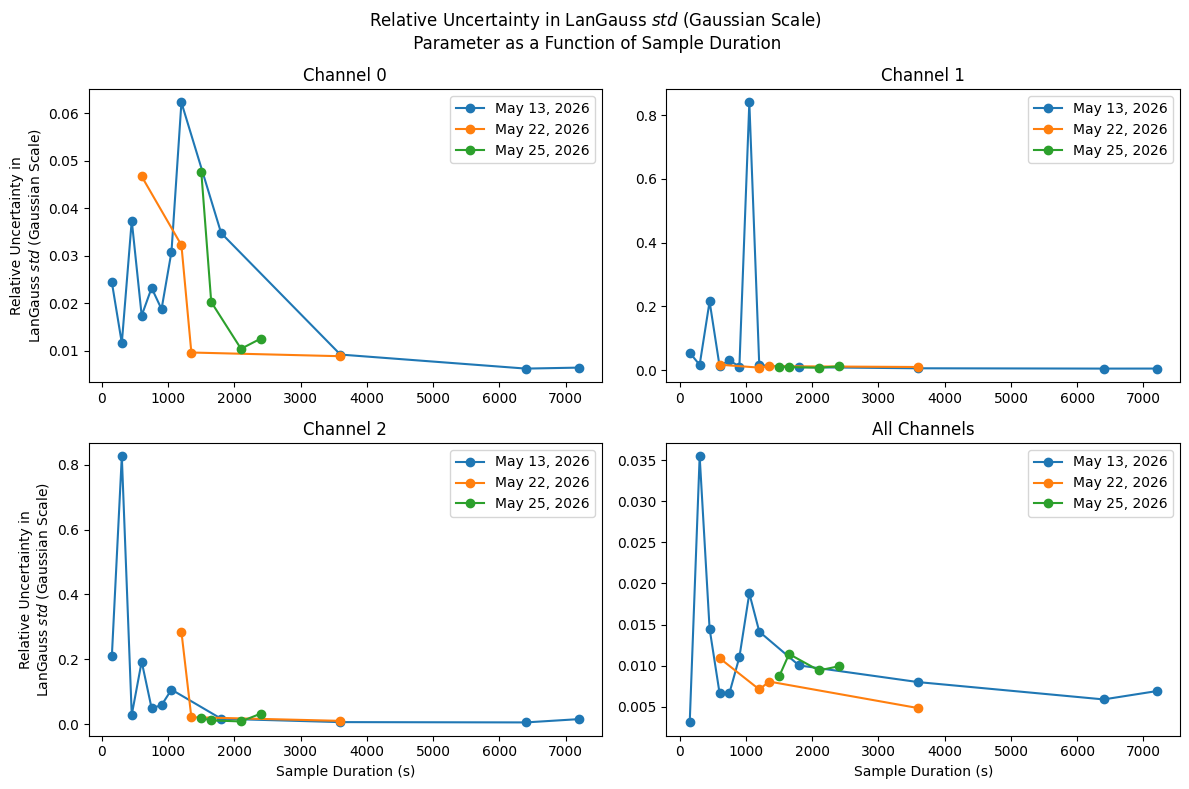

In [124]:
for l in range(len(parameter_labels)):
   title = "Relative Uncertainty in " + parameter_labels[l] + "\n Parameter as a Function of Sample Duration"
   ylabel = "Relative Uncertainty in\n" + parameter_labels[l]
   fig, axs = plt.subplots(2,2,figsize=(12,8))
   plt.suptitle(title)
   axs[0,0].set_ylabel(ylabel)
   axs[1,0].set_ylabel(ylabel)
   axs[1,0].set_xlabel("Sample Duration (s)")
   axs[1,1].set_xlabel("Sample Duration (s)")
   for i in range(2):
      for j in range(2):
         ch = i*2+j
         axs[i,j].set_title(f"Channel {ch}")
         for k in range(len(new_days)):
            # Apply a mask
            mask = (langaus_data[k][ch][5+l]/langaus_data[k][ch][1+l]<1) & (langaus_data[k][ch][5+l]/langaus_data[k][ch][1+l]>0)
            axs[i,j].plot(np.array(new_durations[k])[mask],langaus_data[k][ch][5+l][mask]/langaus_data[k][ch][1+l][mask],label=f"{new_days[k]}",marker='o',linestyle='-')
                  
         axs[i,j].legend()
   axs[1,1].set_title(f"All Channels")

   plt.tight_layout()
   plt.show()

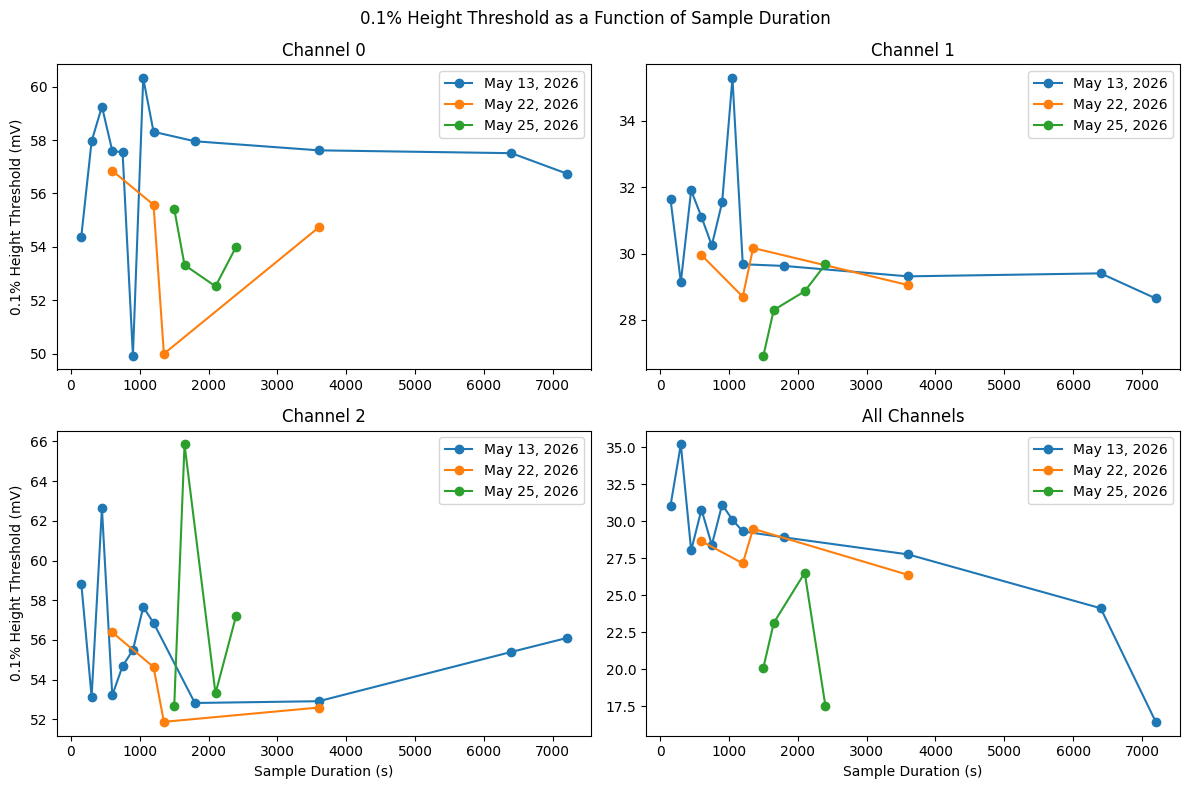

In [127]:
fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle("0.1% Height Threshold as a Function of Sample Duration")
axs[0,0].set_ylabel("0.1% Height Threshold (mV)")
axs[1,0].set_ylabel("0.1% Height Threshold (mV)")
axs[1,0].set_xlabel("Sample Duration (s)")
axs[1,1].set_xlabel("Sample Duration (s)")
for i in range(2):
   for j in range(2):
      ch = i*2+j
      axs[i,j].set_title(f"Channel {ch}")
      for k in range(len(new_days)):
         axs[i,j].plot(new_durations[k],langaus_data[k][ch][9],label=f"{new_days[k]}",marker='o',linestyle='-')
      axs[i,j].legend()
axs[1,1].set_title(f"All Channels")

plt.tight_layout()
plt.show()

In [ ]:
energy_data = []
for i in range(len(new_days)):
   day = new_days[i][4:6]
   df = pd.concat([pd.read_excel(f"timing_results/May{day}_{j}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for j in range(1,new_sizes[i]+1)])
   df = df.sort_values(by='Channel',kind='mergesort')
   grouped = [group for _, group in df.groupby('Channel')]
   day_stats = []
   for ch in grouped:
      ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['K'], ch['mean'], ch['std'], ch['sigma_K'], ch['sigma_mean'], ch['sigma_std'], ch['0.10% Threshold']])
      day_stats.append(ch_stats)
   energy_data.append(np.array(day_stats))

print(len(energy_data))
print([energy_data[i].shape for i in range(len(energy_data))])

print("Days, Channel, Stat, Sample")

3
[(4, 8, 12), (4, 8, 4), (4, 8, 4)]
Days, Channel, Stat, Sample


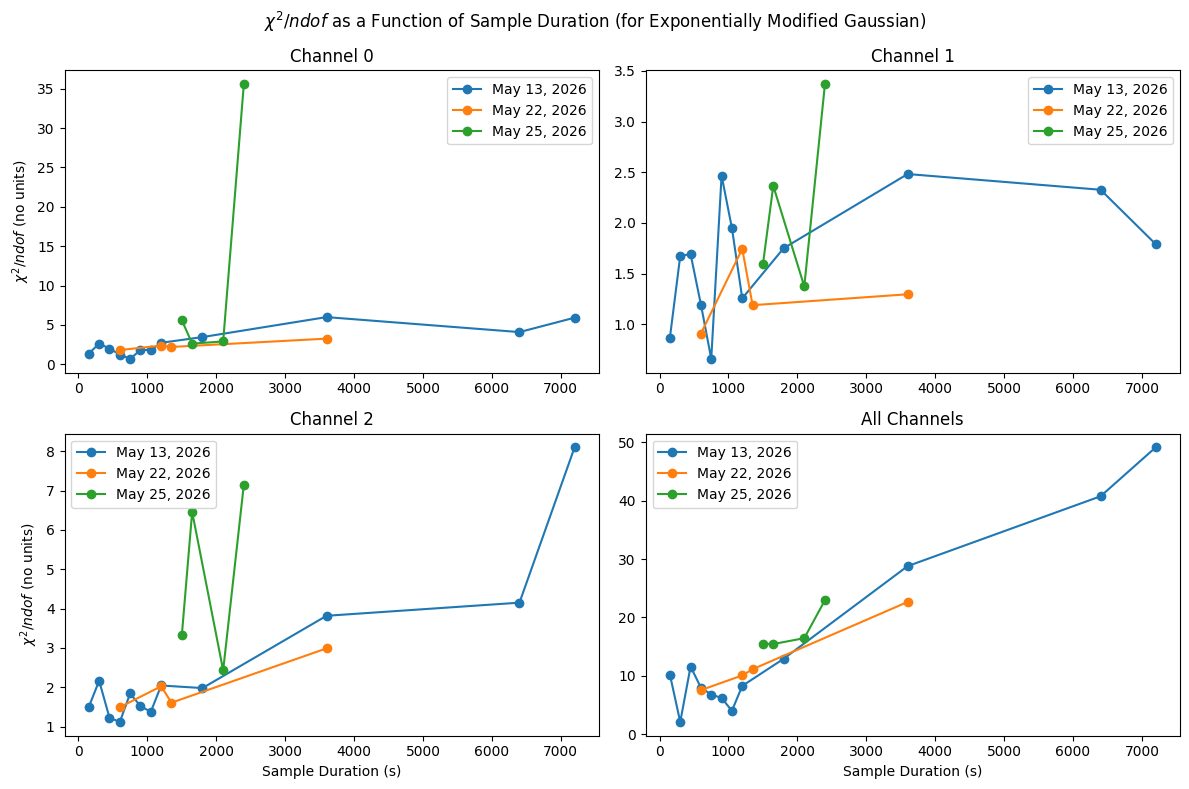

In [130]:
fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle(r"$\chi^2/ndof$ as a Function of Sample Duration (for Exponentially Modified Gaussian)")
axs[0,0].set_ylabel(r"$\chi^2/ndof$ (no units)")
axs[1,0].set_ylabel(r"$\chi^2/ndof$ (no units)")
axs[1,0].set_xlabel("Sample Duration (s)")
axs[1,1].set_xlabel("Sample Duration (s)")
for i in range(2):
   for j in range(2):
      ch = i*2+j
      axs[i,j].set_title(f"Channel {ch}")
      for k in range(len(new_days)):
         axs[i,j].plot(new_durations[k],energy_data[k][ch][0],label=f"{new_days[k]}",marker='o',linestyle='-')
      axs[i,j].legend()
axs[1,1].set_title(f"All Channels")

plt.tight_layout()
plt.show()

# fig, axs = plt.subplots(2,2,figsize=(12,8))
# plt.suptitle(r"$\chi^2/ndof$ as a Function of Sample Duration (for Exponentially Modified Gaussian)")
# axs[0,0].set_ylabel(r"$\chi^2/ndof$ (no units)")
# axs[1,0].set_ylabel(r"$\chi^2/ndof$ (no units)")
# axs[1,0].set_xlabel("Sample Duration (s)")
# axs[1,1].set_xlabel("Sample Duration (s)")
# for i in range(2):
#    for j in range(2):
#       ch = i*2+j
#       axs[i,j].set_title(f"Channel {ch}")
#       for k in range(len(days)):
#          if k not in [1,4]:
#             axs[i,j].plot(durations[k],energy_data[k][ch][0],label=f"{days[k]}",marker='o',linestyle='-')
#       axs[i,j].legend()
# axs[1,1].set_title(f"All Channels")

# plt.tight_layout()
# plt.show()

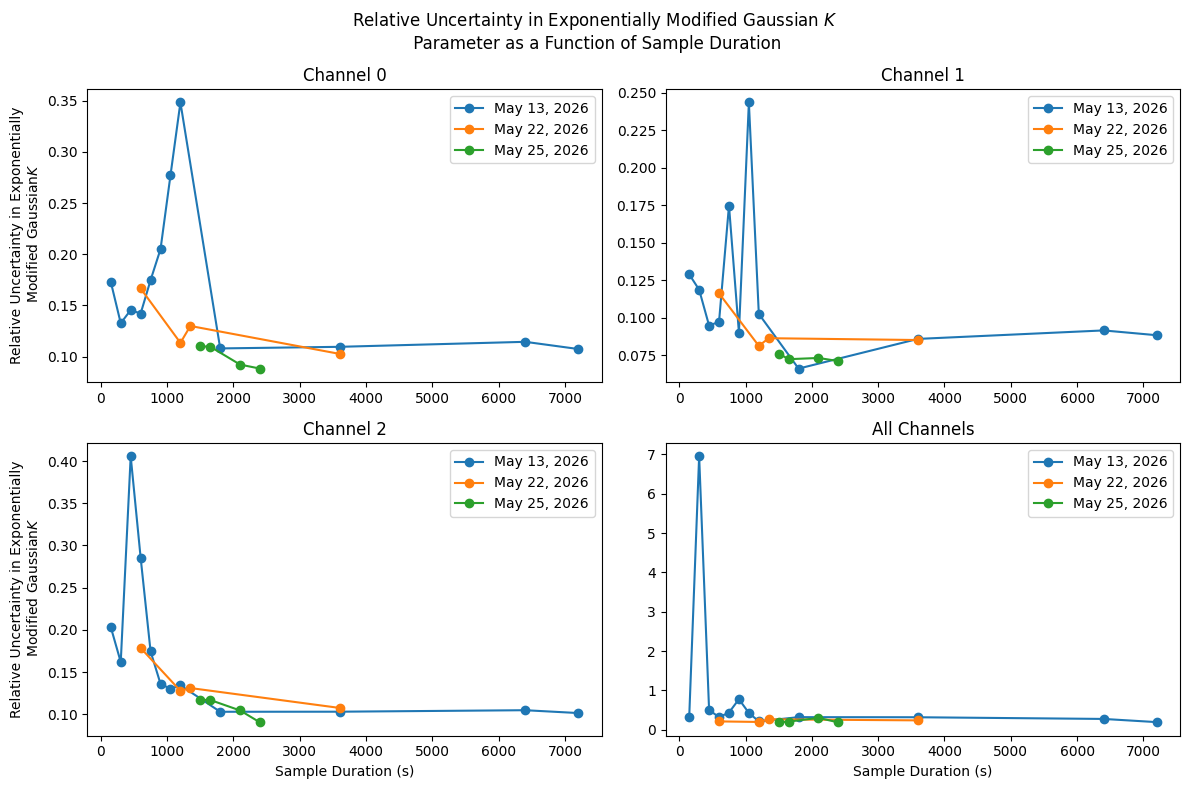

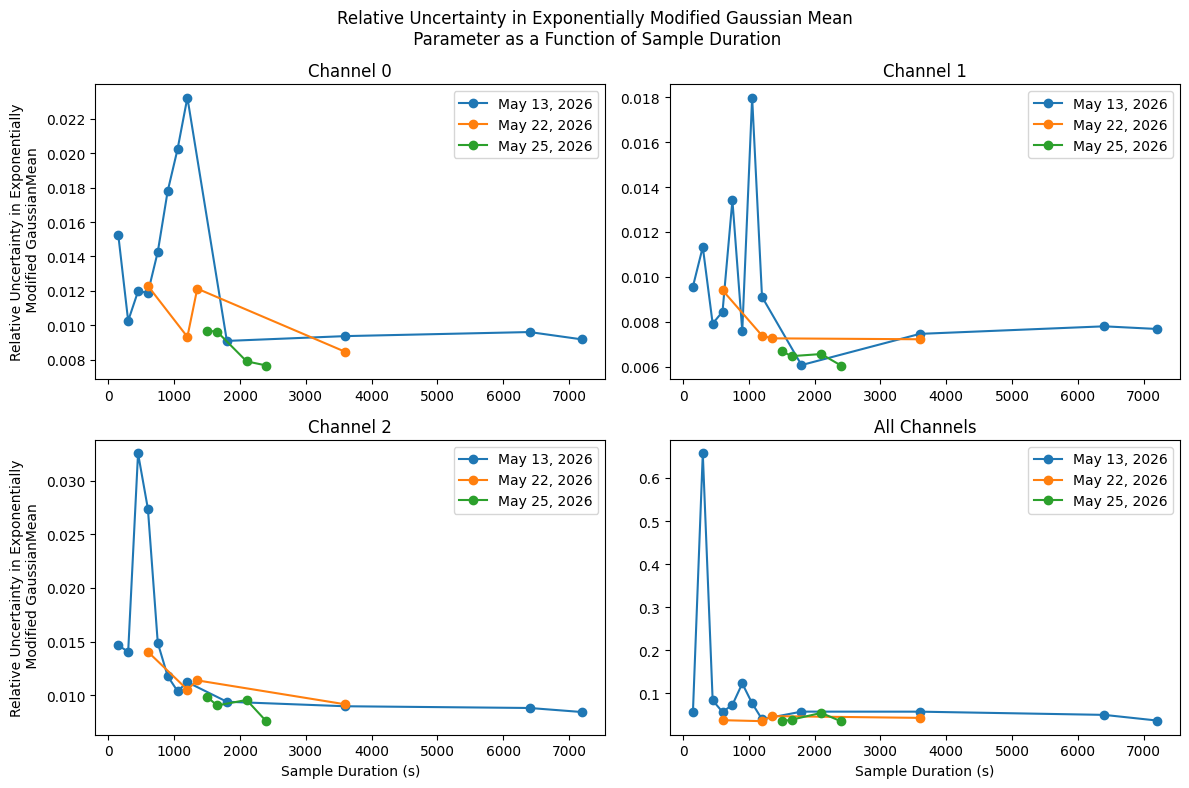

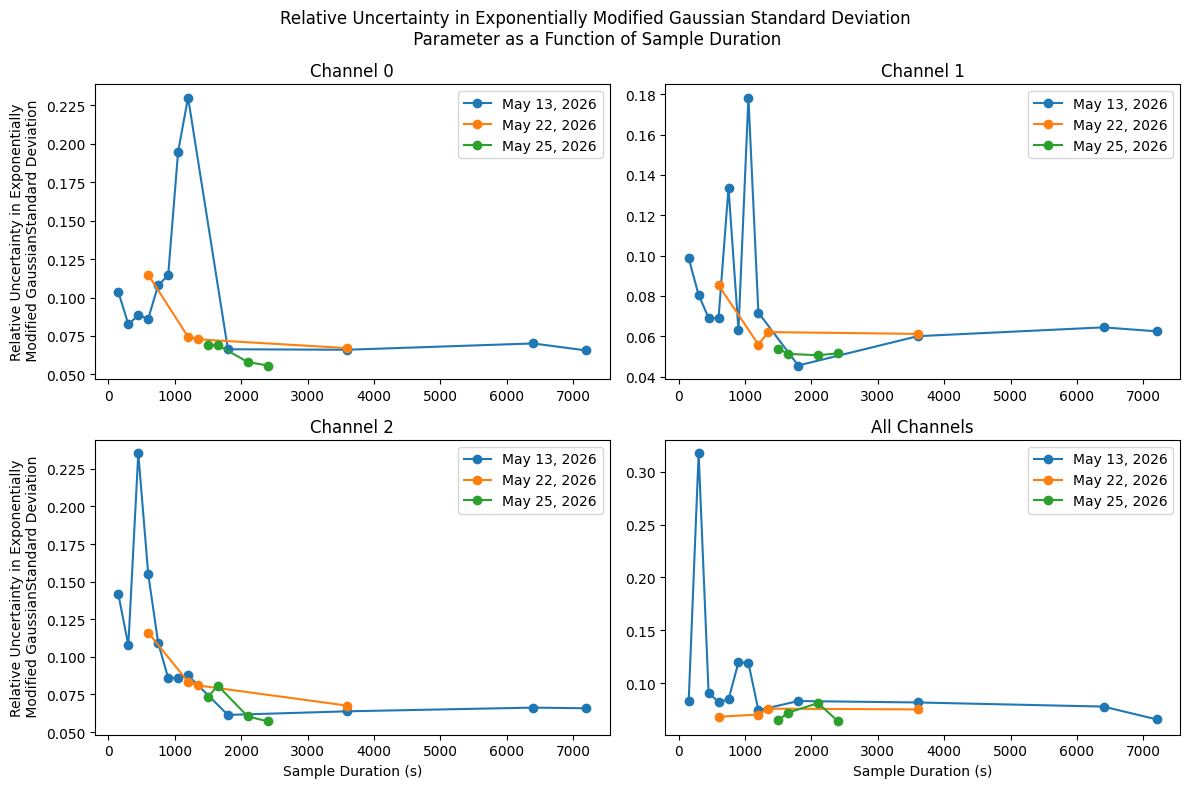

In [131]:
parameter_labels = [
   '$K$',
   'Mean',
   'Standard Deviation'
]


for l in range(len(parameter_labels)):
   title = "Relative Uncertainty in Exponentially Modified Gaussian " + parameter_labels[l] + "\n Parameter as a Function of Sample Duration"
   ylabel = "Relative Uncertainty in Exponentially\n Modified Gaussian" + parameter_labels[l]
   fig, axs = plt.subplots(2,2,figsize=(12,8))
   plt.suptitle(title)
   axs[0,0].set_ylabel(ylabel)
   axs[1,0].set_ylabel(ylabel)
   axs[1,0].set_xlabel("Sample Duration (s)")
   axs[1,1].set_xlabel("Sample Duration (s)")
   for i in range(2):
      for j in range(2):
         ch = i*2+j
         axs[i,j].set_title(f"Channel {ch}")
         for k in range(len(new_days)):
            axs[i,j].plot(new_durations[k],energy_data[k][ch][4+l]/energy_data[k][ch][1+l],label=f"{new_days[k]}",marker='o',linestyle='-')
            # for p in range(len(durations[k])):
            #    if durations[k][p]==1050 and ch==2:
            #       print(f"{energy_data[k][ch][1+l][p]} pm {energy_data[k][ch][5+l][p]}")
                  
         axs[i,j].legend()
   axs[1,1].set_title(f"All Channels")

   plt.tight_layout()
   plt.show()

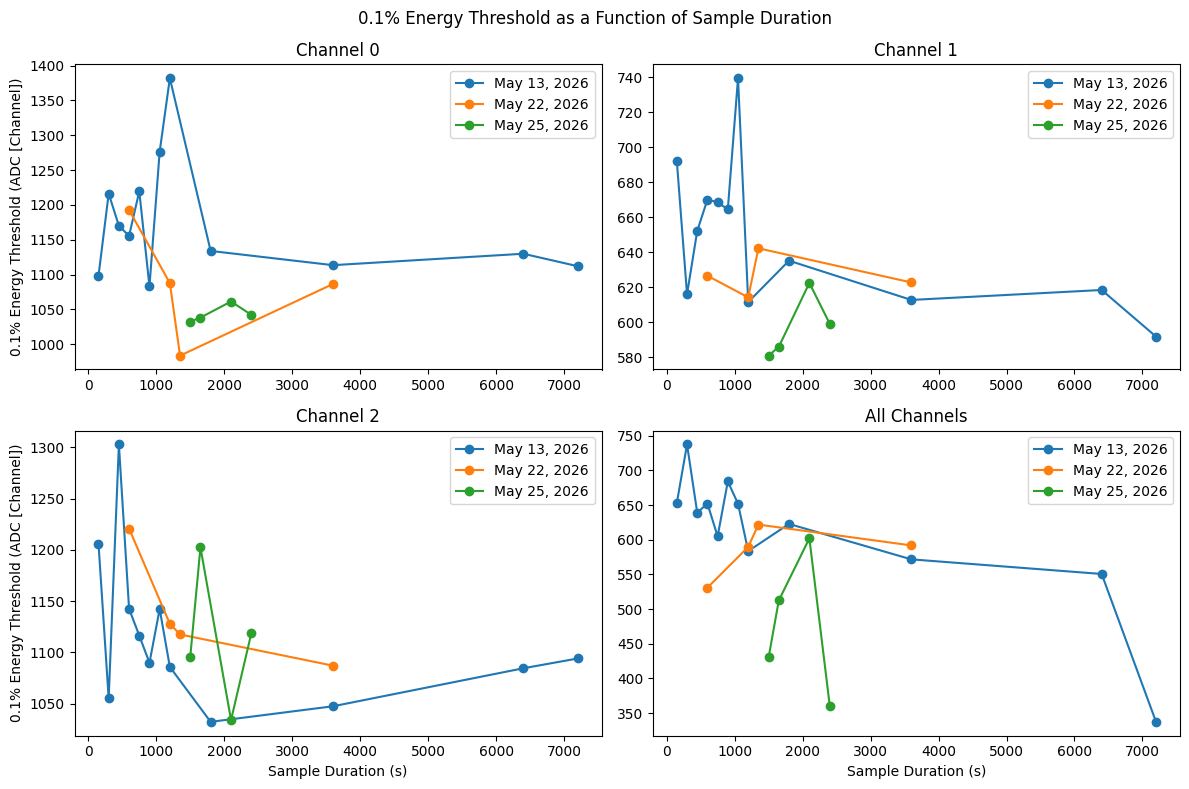

In [133]:
fig, axs = plt.subplots(2,2,figsize=(12,8))
plt.suptitle("0.1% Energy Threshold as a Function of Sample Duration")
axs[0,0].set_ylabel("0.1% Energy Threshold (ADC [Channel])")
axs[1,0].set_ylabel("0.1% Energy Threshold (ADC [Channel])")
axs[1,0].set_xlabel("Sample Duration (s)")
axs[1,1].set_xlabel("Sample Duration (s)")
for i in range(2):
   for j in range(2):
      ch = i*2+j
      axs[i,j].set_title(f"Channel {ch}")
      for k in range(len(new_days)):
         axs[i,j].plot(new_durations[k],energy_data[k][ch][7],label=f"{new_days[k]}",marker='o',linestyle='-')
      axs[i,j].legend()
axs[1,1].set_title(f"All Channels")

plt.tight_layout()
plt.show()